In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = r"P1_Global-AT-ERA5_43.345936_12.591365_3000_27780_1996-01-01_2025-12-31_.csv"

# This file has 15 metadata lines before the actual table starts
df = pd.read_csv(file, skiprows=15)

# Rename columns to simpler names
df = df.rename(columns={
    "datetime (ISO 8601) [UTC]": "datetime",
    "Wind Speed at 10m (WS_10) [m/s]": "WS10",
    "Wind Direction at 10m (WD_10) [\\Deg.N-from]": "WD10",
    "Air Pressure at Mean Sea Level (P_Air) [hPa]": "Pair",
    "Wind Speed at 100m (WS_100) [m/s]": "WS100",
    "Wind Direction at 100m (WD_100) [\\Deg.N-from]": "WD100",
    "Wind Speed at 10m - Adjusted for wave model forcing (WS_10) [m/s]": "WS10_adjusted"
})

# Convert datetime column
df["datetime"] = pd.to_datetime(df["datetime"])

# Replace fill values with NaN
df = df.replace(-9999, np.nan)

# Add month and year columns
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["month_name"] = df["datetime"].dt.month_name()

print(df.head())

             datetime   WS10    WD10     Pair  WS100   WD100  WS10_adjusted  \
0 1996-01-01 00:00:00   9.87  125.83  1013.93  12.03  125.90           9.87   
1 1996-01-01 01:00:00  10.07  125.14  1013.98  12.36  125.19          10.07   
2 1996-01-01 02:00:00  10.11  124.38  1014.04  12.44  124.42          10.11   
3 1996-01-01 03:00:00  10.31  124.06  1014.31  12.72  123.96          10.31   
4 1996-01-01 04:00:00  10.58  123.97  1014.92  12.99  123.89          10.58   

   year  month month_name  
0  1996      1    January  
1  1996      1    January  
2  1996      1    January  
3  1996      1    January  
4  1996      1    January  


In [12]:
print("Number of rows:", len(df))
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print("Years:", df["year"].min(), "-", df["year"].max())
print("Months in file:", sorted(df["month"].unique()))

Number of rows: 262992
Start: 1996-01-01 00:00:00
End: 2025-12-31 23:00:00
Years: 1996 - 2025
Months in file: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


In [13]:
summary = {
    "number_of_records": len(df),
    "start_date": df["datetime"].min(),
    "end_date": df["datetime"].max(),
    "mean_WS10": df["WS10"].mean(),
    "max_WS10": df["WS10"].max(),
    "mean_WS100": df["WS100"].mean(),
    "max_WS100": df["WS100"].max(),
    "mean_pressure": df["Pair"].mean()
}

summary_df = pd.DataFrame([summary])

print(summary_df)

summary_df.to_csv("wind_summary_bab_el_mandeb.csv", index=False)

   number_of_records start_date            end_date  mean_WS10  max_WS10  \
0             262992 1996-01-01 2025-12-31 23:00:00    6.81513     14.09   

   mean_WS100  max_WS100  mean_pressure  
0    8.402445      18.15    1009.074024  


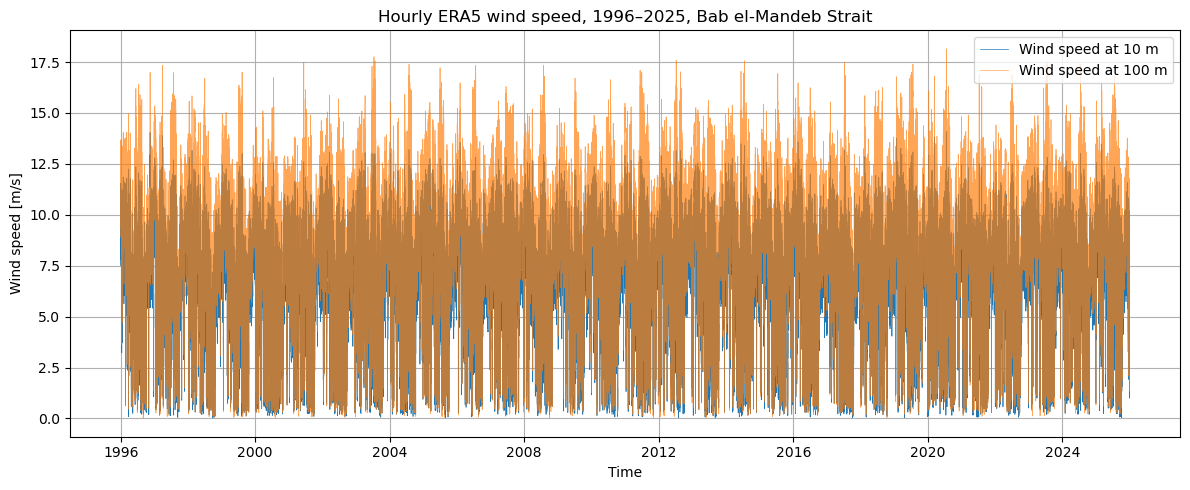

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(df["datetime"], df["WS10"], label="Wind speed at 10 m", linewidth=0.5)
plt.plot(df["datetime"], df["WS100"], label="Wind speed at 100 m", linewidth=0.5, alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Wind speed [m/s]")
plt.title("Hourly ERA5 wind speed, 1996–2025, Bab el-Mandeb Strait")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

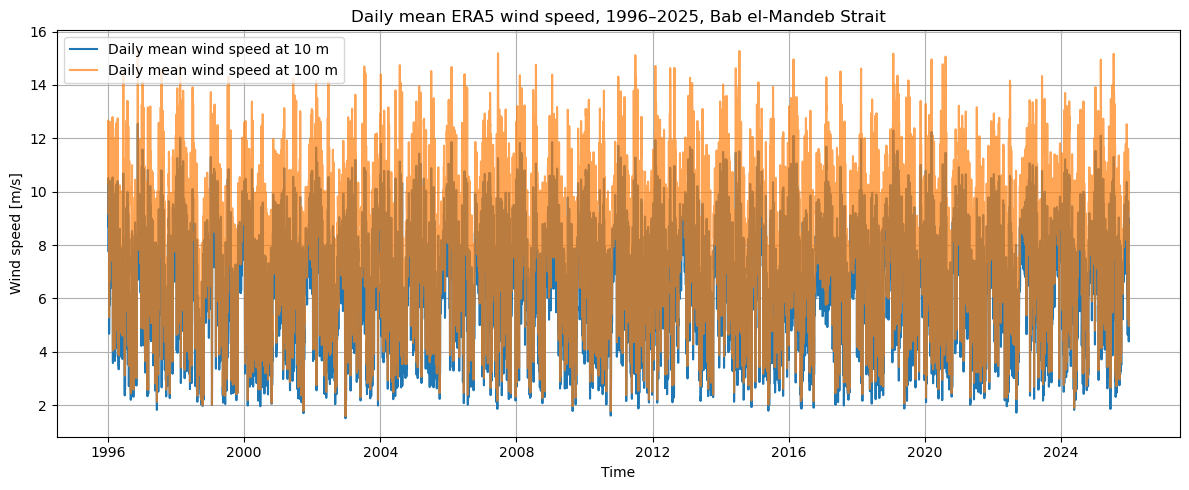

In [15]:
df_daily = df.set_index("datetime")[["WS10", "WS100"]].resample("D").mean()

plt.figure(figsize=(12, 5))

plt.plot(df_daily.index, df_daily["WS10"], label="Daily mean wind speed at 10 m")
plt.plot(df_daily.index, df_daily["WS100"], label="Daily mean wind speed at 100 m", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Wind speed [m/s]")
plt.title("Daily mean ERA5 wind speed, 1996–2025, Bab el-Mandeb Strait")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
monthly_average = df.groupby(["month", "month_name"]).agg(
    mean_WS10=("WS10", "mean"),
    max_WS10=("WS10", "max"),
    mean_WS100=("WS100", "mean"),
    max_WS100=("WS100", "max"),
    mean_pressure=("Pair", "mean")
).reset_index()

monthly_average = monthly_average.sort_values("month")

print(monthly_average)

monthly_average.to_csv("monthly_average_wind_bab_el_mandeb.csv", index=False)

    month month_name  mean_WS10  max_WS10  mean_WS100  max_WS100  \
0       1    January   8.055341     13.77    9.604102      16.78   
1       2   February   7.991016     13.58    9.551119      16.48   
2       3      March   7.754924     13.89    9.363797      17.34   
3       4      April   7.180905     13.06    8.725740      15.85   
4       5        May   5.573547     12.03    6.827030      14.53   
5       6       June   5.801786     13.49    7.727744      17.50   
6       7       July   6.912589     14.09    9.417950      18.15   
7       8     August   5.702640     13.15    7.612846      17.02   
8       9  September   5.005906     12.75    6.197516      16.21   
9      10    October   6.400871     11.59    7.495390      13.63   
10     11   November   7.635213     14.04    9.052576      16.99   
11     12   December   7.817702     12.93    9.293321      15.48   

    mean_pressure  
0     1014.532905  
1     1013.483077  
2     1011.279332  
3     1009.204104  
4     1006.9215

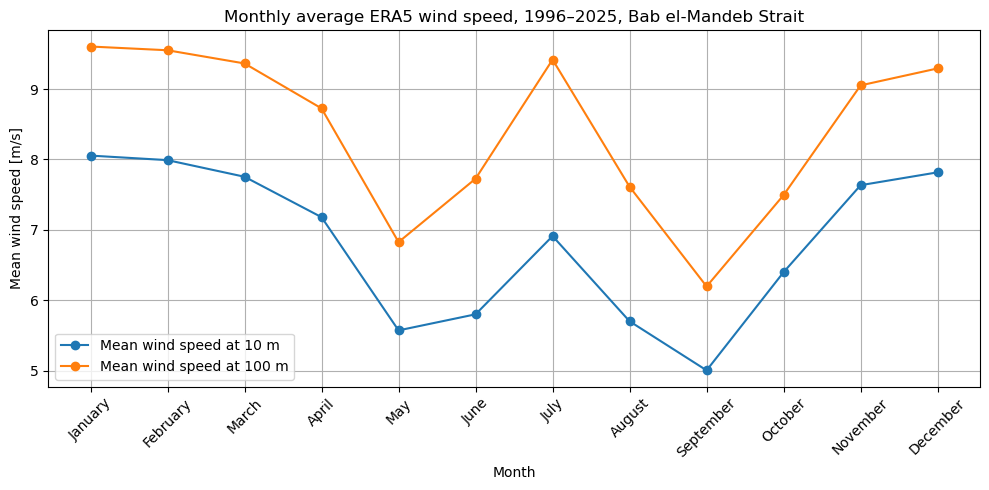

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_average["month_name"],
    monthly_average["mean_WS10"],
    marker="o",
    label="Mean wind speed at 10 m"
)

plt.plot(
    monthly_average["month_name"],
    monthly_average["mean_WS100"],
    marker="o",
    label="Mean wind speed at 100 m"
)

plt.xlabel("Month")
plt.ylabel("Mean wind speed [m/s]")
plt.title("Monthly average ERA5 wind speed, 1996–2025, Bab el-Mandeb Strait")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
def compass_direction(deg):
    directions = [
        "N", "NNE", "NE", "ENE",
        "E", "ESE", "SE", "SSE",
        "S", "SSW", "SW", "WSW",
        "W", "WNW", "NW", "NNW"
    ]
    index = int((deg + 11.25) % 360 / 22.5)
    return directions[index]


def mean_wind_direction(group, direction_col, speed_col):
    data = group[[direction_col, speed_col]].dropna()
    
    if len(data) == 0:
        return np.nan
    
    direction_rad = np.deg2rad(data[direction_col])
    wind_speed = data[speed_col]
    
    x = np.mean(wind_speed * np.sin(direction_rad))
    y = np.mean(wind_speed * np.cos(direction_rad))
    
    mean_direction = np.rad2deg(np.arctan2(x, y))
    mean_direction = (mean_direction + 360) % 360
    
    return mean_direction


monthly_direction = df.groupby(["month", "month_name"]).apply(
    lambda x: mean_wind_direction(x, "WD10", "WS10")
).reset_index(name="mean_WD10")

monthly_direction["compass_direction"] = monthly_direction["mean_WD10"].apply(compass_direction)

monthly_direction = monthly_direction.sort_values("month")

print(monthly_direction)

monthly_direction.to_csv("monthly_average_wind_direction_bab_el_mandeb.csv", index=False)

    month month_name   mean_WD10 compass_direction
0       1    January  130.742158                SE
1       2   February  132.516160                SE
2       3      March  135.371192                SE
3       4      April  136.942190                SE
4       5        May  125.731002                SE
5       6       June  322.098696                NW
6       7       July  314.310090                NW
7       8     August  316.693512                NW
8       9  September  348.190272               NNW
9      10    October  133.532836                SE
10     11   November  135.875368                SE
11     12   December  134.842860                SE


C:\Users\jholl\AppData\Local\Temp\ipykernel_1772\2036645002.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_direction = df.groupby(["month", "month_name"]).apply(


In [19]:
monthly_table = monthly_average.merge(
    monthly_direction[["month", "mean_WD10", "compass_direction"]],
    on="month"
)

monthly_table = monthly_table[[
    "month",
    "month_name",
    "mean_WS10",
    "max_WS10",
    "mean_WS100",
    "max_WS100",
    "mean_WD10",
    "compass_direction",
    "mean_pressure"
]]

print(monthly_table)

monthly_table.to_csv("monthly_wind_climate_bab_el_mandeb.csv", index=False)

    month month_name  mean_WS10  max_WS10  mean_WS100  max_WS100   mean_WD10  \
0       1    January   8.055341     13.77    9.604102      16.78  130.742158   
1       2   February   7.991016     13.58    9.551119      16.48  132.516160   
2       3      March   7.754924     13.89    9.363797      17.34  135.371192   
3       4      April   7.180905     13.06    8.725740      15.85  136.942190   
4       5        May   5.573547     12.03    6.827030      14.53  125.731002   
5       6       June   5.801786     13.49    7.727744      17.50  322.098696   
6       7       July   6.912589     14.09    9.417950      18.15  314.310090   
7       8     August   5.702640     13.15    7.612846      17.02  316.693512   
8       9  September   5.005906     12.75    6.197516      16.21  348.190272   
9      10    October   6.400871     11.59    7.495390      13.63  133.532836   
10     11   November   7.635213     14.04    9.052576      16.99  135.875368   
11     12   December   7.817702     12.9

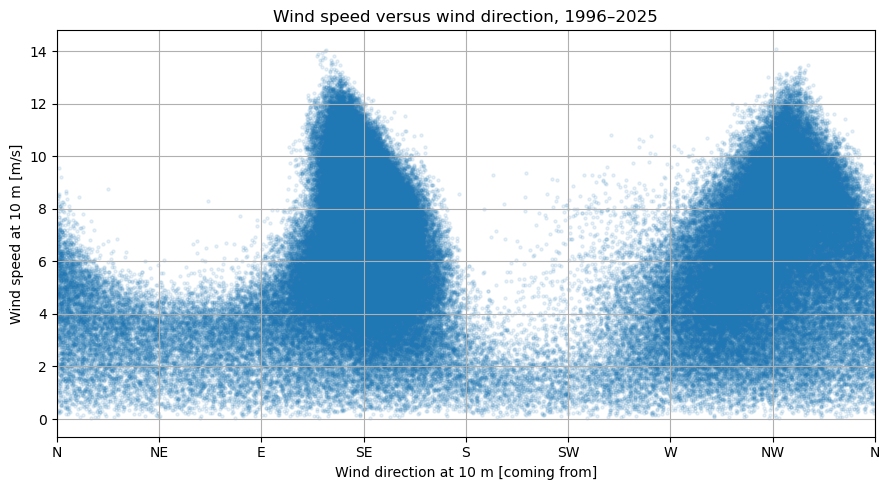

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.scatter(df["WD10"], df["WS10"], alpha=0.1, s=5)

plt.xlabel("Wind direction at 10 m [coming from]")
plt.ylabel("Wind speed at 10 m [m/s]")
plt.title("Wind speed versus wind direction, 1996–2025")

# Compass labels on x-axis
plt.xticks(
    ticks=[0, 45, 90, 135, 180, 225, 270, 315, 360],
    labels=["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
)

plt.xlim(0, 360)
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
df["direction_sector"] = df["WD10"].apply(compass_direction)

direction_table = df.groupby("direction_sector").agg(
    count=("WS10", "count"),
    mean_WS10=("WS10", "mean"),
    max_WS10=("WS10", "max")
).reset_index()

direction_table["frequency_%"] = 100 * direction_table["count"] / len(df)

print(direction_table)

direction_table.to_csv("wind_direction_frequency_bab_el_mandeb.csv", index=False)

   direction_sector   count  mean_WS10  max_WS10  frequency_%
0                 E    3831   3.511861      8.34     1.456698
1               ENE    2405   2.915609      8.28     0.914476
2               ESE   24098   6.867618     14.04     9.163016
3                 N    6450   4.998834     10.98     2.452546
4                NE    2172   2.860046      6.05     0.825881
5               NNE    2992   3.338556      8.76     1.137677
6               NNW   18779   7.148041     13.49     7.140521
7                NW   28347   7.318228     14.09    10.778655
8                 S    2173   3.138776      8.74     0.826261
9                SE  117569   7.760995     13.47    44.704402
10              SSE   25911   6.101630     11.68     9.852391
11              SSW     828   1.980024      9.36     0.314838
12               SW    1034   2.575300      9.30     0.393168
13                W    6304   4.269665     10.78     2.397031
14              WNW   17830   5.604382     12.00     6.779674
15      

In [22]:
df.to_csv("cleaned_ERA5_wind_bab_el_mandeb_1996_2025.csv", index=False)